# Notebook 07 — Explicabilidad con SHAP

Proyecto: Clasificación de ensayos EEG [match vs mismatch].  
Track elegido: Track A - ML Clásico  
Autores: Jose Pablo Agüero Mora, Roilin Navarro Vargas

## Objetivo

Se analiza la interpretabilidad del modelo final (LightGBM) usando SHAP. El objetivo es entender qué features están influyendo más en las predicciones y revisar si esas features tienen sentido con lo que se observó en el análisis estadístico del Notebook 02.

El análisis se hace principalmente sobre el conjunto holdout para que la explicación no esté basada en los mismos sujetos usados durante entrenamiento y selección del modelo. Se generan resultados globales (ranking e información agregada) y resultados locales (explicaciones de casos específicos).


## 1. Configuración

In [4]:
PROJECT_ROOT_DRIVE = '/content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400'
print(f'PROJECT_ROOT_DRIVE: {PROJECT_ROOT_DRIVE}')

PROJECT_ROOT_DRIVE: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400


## 2. Instalación + reinicio

In [1]:
%%capture
!pip install -q --upgrade --no-cache-dir "shap>=0.46.0"
!pip install -q mne==1.12.1
!pip install -q scikit-learn xgboost lightgbm optuna
!pip install -q pyxdf openpyxl pyyaml tqdm jedi

In [ ]:
import os
os.kill(os.getpid(), 9)

## 3. Imports

In [2]:
import os
import sys
import json
import yaml
import random
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

print(f'Python:  {sys.version.split()[0]}')
print(f'NumPy:   {np.__version__}')
print(f'SHAP:    {shap.__version__}')

Python:  3.12.13
NumPy:   2.0.2
SHAP:    0.52.0


## 4. Drive, carga del modelo y datos

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

CONFIG_PATH = Path(PROJECT_ROOT_DRIVE) / 'configs' / 'main_config.yaml'
with open(CONFIG_PATH, 'r') as f:
    CFG = yaml.safe_load(f)

SEED = CFG['seed']
random.seed(SEED)
np.random.seed(SEED)

REPORTS_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['reports_dir']
FIGURES_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['figures_dir']
FEATURES_DIR = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['features_dir']
MODELS_DIR   = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['models_dir']

# Modelo final
with open(MODELS_DIR / 'best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

with open(MODELS_DIR / 'best_hyperparameters.json', 'r') as f:
    best_info = json.load(f)

with open(MODELS_DIR / 'holdout_split.json', 'r') as f:
    split_info = json.load(f)

# Diccionario de features
with open(REPORTS_DIR / '02_feature_dictionary.json', 'r') as f:
    feature_dictionary = json.load(f)

# Análisis univariado del Notebook 02 (para validación teórica)
df_univ = pd.read_csv(REPORTS_DIR / '02_univariate_feature_analysis.csv')

print(f' Modelo cargado: {best_info["winner_name"]}')
print(f' CV Macro F1: {best_info["cv_f1_macro"]:.3f}')
print(f' {len(feature_dictionary)} features en diccionario')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Modelo cargado: LightGBM_tuned
 CV Macro F1: 0.558
 72 features en diccionario


In [6]:
# Cargar features
df = pd.read_csv(FEATURES_DIR / '02_features_matrix.csv')
feature_cols = [c for c in df.columns if c not in ['subject_id', 'epoch_idx', 'condition', 'label']]

# Conjuntos CV y HOLDOUT
df_cv = df[df['subject_id'].isin(split_info['cv_subjects'])].reset_index(drop=True)
df_ho = df[df['subject_id'].isin(split_info['holdout_subjects'])].reset_index(drop=True)

X_cv_raw = df_cv[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
X_ho_raw = df_ho[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

y_ho = df_ho['label'].values

print(f'CV:      {X_cv_raw.shape}')
print(f'HOLDOUT: {X_ho_raw.shape}')

CV:      (1238, 72)
HOLDOUT: (265, 72)


## 5. Construir el TreeExplainer

Como el modelo final es un modelo basado en árboles (LightGBM), se utiliza shap.TreeExplainer para calcular contribuciones por feature. El modelo se entrenó dentro de un pipeline con StandardScaler, por lo que las explicaciones se calculan sobre las features estandarizadas (las mismas que recibe el clasificador).

Para que el análisis sea consistente, se calculan los SHAP values usando el conjunto holdout.

In [7]:
# Aplicar el StandardScaler del pipeline (ya entrenado en CV)
scaler = best_model.named_steps['scaler']
clf    = best_model.named_steps['clf']

X_cv_scaled = scaler.transform(X_cv_raw)
X_ho_scaled = scaler.transform(X_ho_raw)

# Convertir a DataFrame para que SHAP use los nombres de columnas
X_cv_scaled_df = pd.DataFrame(X_cv_scaled, columns=feature_cols)
X_ho_scaled_df = pd.DataFrame(X_ho_scaled, columns=feature_cols)

# Construir explainer
explainer = shap.TreeExplainer(clf)
print(f' TreeExplainer construido sobre {type(clf).__name__}')

# Calcular SHAP values sobre el holdout (más limpio interpretativamente)
# Para LightGBM con clasificación binaria, devuelve un array (n_samples, n_features)
# o un Explanation object dependiendo de la versión
shap_values_obj = explainer(X_ho_scaled_df)

# Manejar diferentes formatos de retorno
if hasattr(shap_values_obj, 'values'):
    shap_values = shap_values_obj.values
    if shap_values.ndim == 3:    # (n_samples, n_features, n_classes)
        shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values_obj
    if isinstance(shap_values, list):
        shap_values = shap_values[1]   # clase mismatch

print(f' SHAP values calculados: {shap_values.shape}')
print(f' ({X_ho_scaled.shape[0]} epochs del holdout × {X_ho_scaled.shape[1]} features)')

 TreeExplainer construido sobre LGBMClassifier
 SHAP values calculados: (265, 72)
 (265 epochs del holdout × 72 features)


## 6. Importancia global de features (ranking)

La importancia global se calcula como el promedio del valor absoluto de los SHAP values por feature. Esto permite ordenar las features por influencia promedio en las predicciones del modelo.

In [8]:
# Importancia global
mean_abs_shap = np.abs(shap_values).mean(axis=0)

df_shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': mean_abs_shap,
    'description': [feature_dictionary.get(f, f) for f in feature_cols]
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

df_shap_importance.to_csv(REPORTS_DIR / '07_shap_feature_importance.csv', index=False)

print('=== TOP 15 DE FEATURES POR IMPORTANCIA SHAP ===\n')
for i, row in df_shap_importance.head(15).iterrows():
    print(f'{i+1:2d}. {row["feature"]:40s}  |SHAP|̄ = {row["mean_abs_shap"]:.4f}')
    print(f'     L- {row["description"]}')

=== TOP 15 DE FEATURES POR IMPORTANCIA SHAP ===

 1. freq_ratio_theta_alpha_AF8_full           |SHAP|̄ = 0.0689
     L- Frecuencial — ratio theta/alpha de AF8 en epoch completa
 2. temp_var_AF7_full                         |SHAP|̄ = 0.0660
     L- Temporal — varianza de AF7 en epoch completa
 3. temp_ptp_AF7_full                         |SHAP|̄ = 0.0590
     L- Temporal — rango peak-to-peak de AF7 en epoch completa
 4. temp_slope_AF7_N400                       |SHAP|̄ = 0.0327
     L- Temporal — pendiente lineal de AF7 en ventana N400 (250-600 ms)
 5. cross_diff_beta_N400                      |SHAP|̄ = 0.0310
     L- Inter-canal — diferencia AF7−AF8 en potencia beta (ventana N400)
 6. temp_slope_AF8_N400                       |SHAP|̄ = 0.0273
     L- Temporal — pendiente lineal de AF8 en ventana N400 (250-600 ms)
 7. cross_diff_theta_full                     |SHAP|̄ = 0.0243
     L- Inter-canal — diferencia AF7−AF8 en potencia theta (epoch completa)
 8. temp_auc_AF8_N400               

## 7. Beeswarm plot: Vista Global

En el beeswarm plot cada punto representa una epoch. El eje X muestra el SHAP value: impacto en la salida del modelo. El color refleja el valor de la feature. Este gráfico ayuda a ver tanto importancia como dirección: si valores altos de una feature tienden a empujar a mismatch o a match.

 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/07_shap_summary_global.png


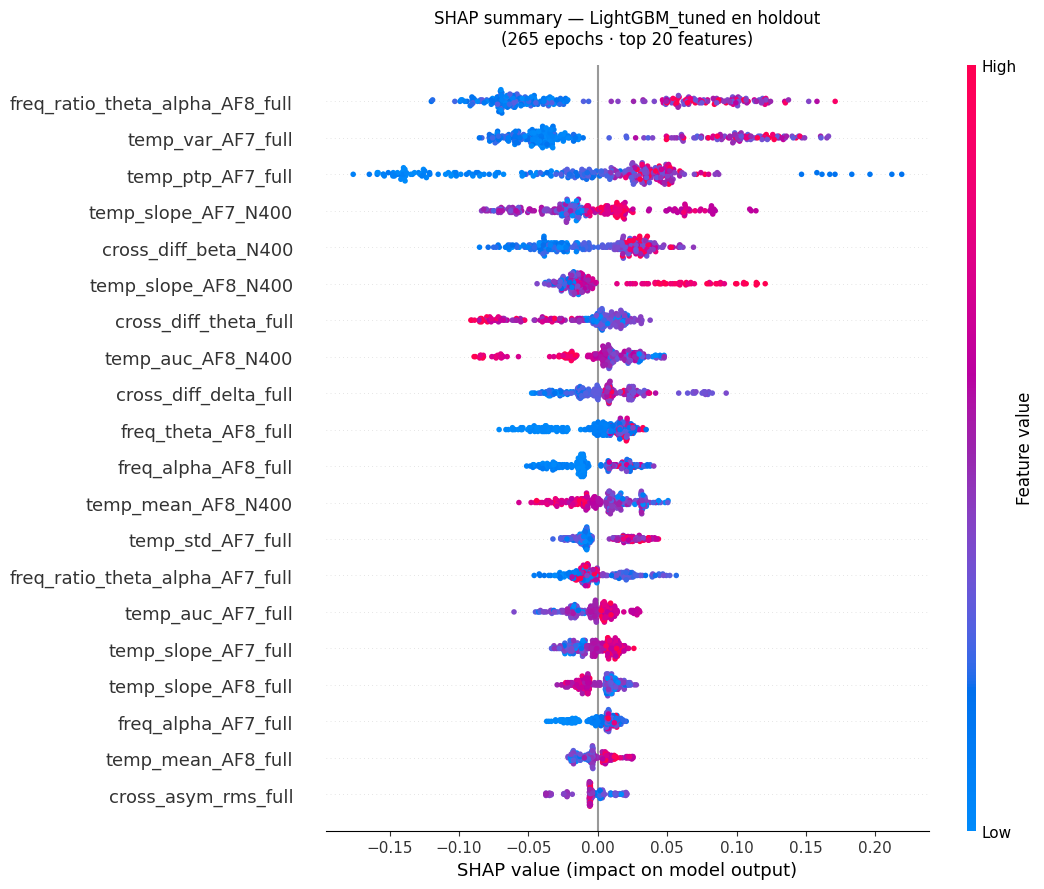

In [9]:
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_ho_scaled_df, max_display=20, show=False, plot_size=None)
fig = plt.gcf()
fig.set_size_inches(11, 9)
plt.title(f'SHAP summary — {best_info["winner_name"]} en holdout\n'
          f'({X_ho_scaled.shape[0]} epochs · top 20 features)', fontsize=12, pad=15)
plt.tight_layout()
fig_path = FIGURES_DIR / '07_shap_summary_global.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

## 8. Comparación: SHAP contra análisis univariado

Aquí se compara el ranking de features por SHAP con el ranking del análisis univariado (Welch t-test) del Notebook 02. La idea es ver si existe coincidencia entre ambos enfoques. Si hay intersección en las top features, eso sugiere consistencia entre el análisis estadístico y lo que el modelo está usando para predecir.

In [10]:
# Top 15 por SHAP
top_shap = set(df_shap_importance.head(15)['feature'])
# Top 15 por análisis univariado: p-value más bajo
top_univ = set(df_univ.head(15)['feature'])

intersection = top_shap & top_univ
shap_only    = top_shap - top_univ
univ_only    = top_univ - top_shap

print(f'=== CONVERGENCIA SHAP - ANÁLISIS UNIVARIADO ===\n')
print(f'Top 15 SHAP y Top 15 univariado: {len(intersection)} features\n')

if len(intersection) > 0:
    print('Features confirmadas por ambos métodos:')
    for f in sorted(intersection):
        shap_rank = df_shap_importance.index[df_shap_importance['feature'] == f].tolist()[0] + 1
        univ_rank = df_univ.index[df_univ['feature'] == f].tolist()[0] + 1
        print(f'  - {f:40s}  rank SHAP: {shap_rank:2d}  *  rank univ: {univ_rank:2d}')

print(f'\nSolo en SHAP top 15: features que el modelo aprovecha pero univariado no detectó:')
for f in sorted(shap_only):
    shap_rank = df_shap_importance.index[df_shap_importance['feature'] == f].tolist()[0] + 1
    univ_rank = df_univ.index[df_univ['feature'] == f].tolist()[0] + 1
    print(f'  - {f:40s}  rank SHAP: {shap_rank:2d}  *  rank univ: {univ_rank:2d}')

print(f'\nSolo en univariado top 15: features individualmente discriminativas que el modelo no usa:')
for f in sorted(univ_only):
    shap_rank = df_shap_importance.index[df_shap_importance['feature'] == f].tolist()[0] + 1
    univ_rank = df_univ.index[df_univ['feature'] == f].tolist()[0] + 1
    print(f'  - {f:40s}  rank SHAP: {shap_rank:2d}  *  rank univ: {univ_rank:2d}')

=== CONVERGENCIA SHAP - ANÁLISIS UNIVARIADO ===

Top 15 SHAP y Top 15 univariado: 4 features

Features confirmadas por ambos métodos:
  - cross_diff_beta_N400                      rank SHAP:  5  *  rank univ:  5
  - temp_ptp_AF7_full                         rank SHAP:  3  *  rank univ:  2
  - temp_std_AF7_full                         rank SHAP: 13  *  rank univ:  1
  - temp_var_AF7_full                         rank SHAP:  2  *  rank univ:  4

Solo en SHAP top 15: features que el modelo aprovecha pero univariado no detectó:
  - cross_diff_delta_full                     rank SHAP:  9  *  rank univ: 62
  - cross_diff_theta_full                     rank SHAP:  7  *  rank univ: 52
  - freq_alpha_AF8_full                       rank SHAP: 11  *  rank univ: 41
  - freq_ratio_theta_alpha_AF7_full           rank SHAP: 14  *  rank univ: 36
  - freq_ratio_theta_alpha_AF8_full           rank SHAP:  1  *  rank univ: 18
  - freq_theta_AF8_full                       rank SHAP: 10  *  rank univ: 16
  -

 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/07_theory_validation.png


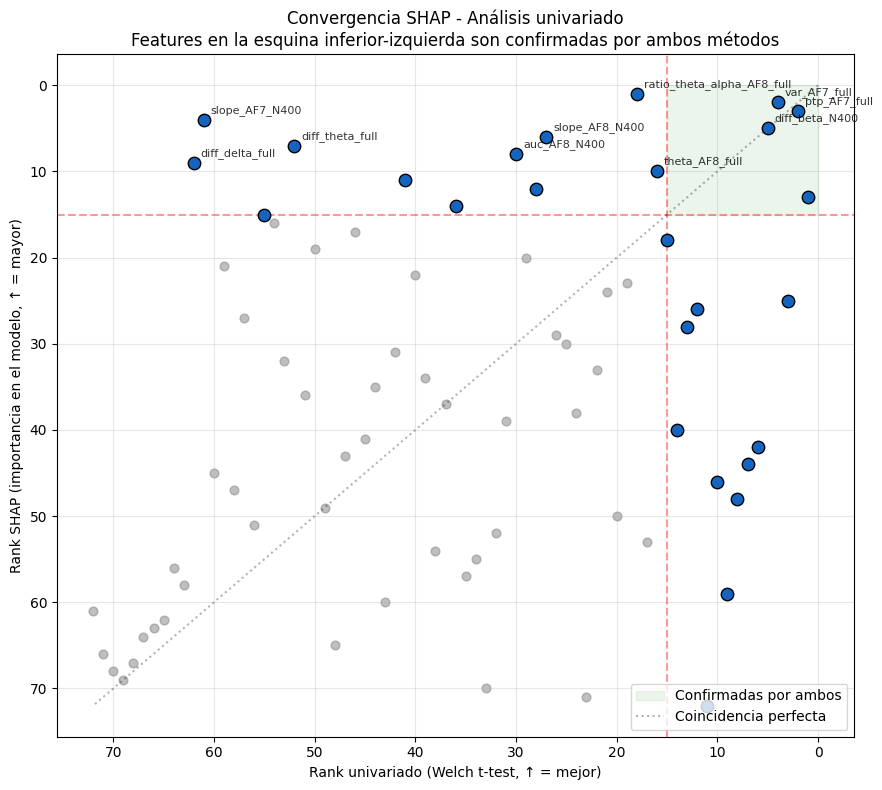

In [11]:
# Visualización: scatter SHAP rank vs Univariate rank
df_shap_importance['shap_rank'] = df_shap_importance.index + 1
df_univ_subset = df_univ.copy()
df_univ_subset['univ_rank'] = df_univ_subset.index + 1

df_compare = df_shap_importance.merge(df_univ_subset[['feature', 'univ_rank']], on='feature', how='left')

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(df_compare['univ_rank'], df_compare['shap_rank'], s=40, alpha=0.5, color='gray')

# Resaltar top 15 en cada eje
top_combined = df_compare[(df_compare['shap_rank'] <= 15) | (df_compare['univ_rank'] <= 15)]
ax.scatter(top_combined['univ_rank'], top_combined['shap_rank'], s=80, color='#1565c0', edgecolor='black', zorder=3)

# Etiquetar top 10 SHAP
for _, row in df_compare.head(10).iterrows():
    ax.annotate(row['feature'].replace('temp_', '').replace('freq_', '').replace('cross_', ''),
                xy=(row['univ_rank'], row['shap_rank']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

# Líneas de top 15
ax.axhline(15, color='red', linestyle='--', alpha=0.4)
ax.axvline(15, color='red', linestyle='--', alpha=0.4)
ax.fill_betweenx([0, 15], 0, 15, color='green', alpha=0.08, label='Confirmadas por ambos')

# Diagonal de coincidencia perfecta
ax.plot([0, 72], [0, 72], 'k:', alpha=0.3, label='Coincidencia perfecta')

ax.set_xlabel('Rank univariado (Welch t-test, ↑ = mejor)')
ax.set_ylabel('Rank SHAP (importancia en el modelo, ↑ = mayor)')
ax.set_title('Convergencia SHAP - Análisis univariado\nFeatures en la esquina inferior-izquierda son confirmadas por ambos métodos')
ax.invert_xaxis()
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = FIGURES_DIR / '07_theory_validation.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

## 9. Análisis por familia de features

Se agrupan las features en tres familias (temporal, frecuencial e inter-canal) y se suma la importancia SHAP promedio dentro de cada grupo. Para ver si el modelo depende más de medidas temporales, de potencia por bandas o de relaciones entre canales.

✓ Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/07_shap_by_category.png


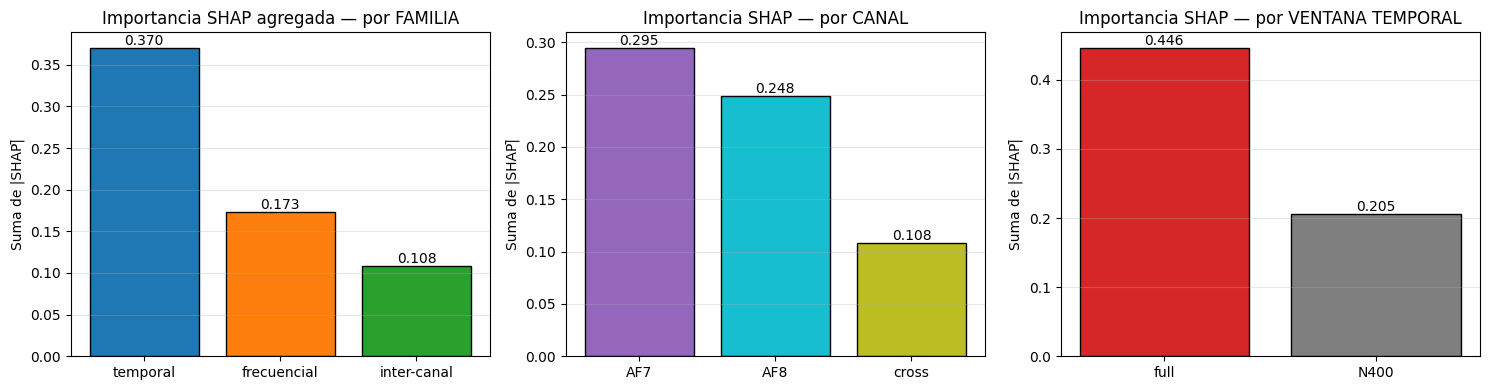


=== RESUMEN POR CATEGORÍA ===

Por familia:
family
temporal       0.370424
frecuencial    0.172698
inter-canal    0.108322

Por canal:
channel
AF7      0.294788
AF8      0.248334
cross    0.108322

Por ventana:
window
full    0.446315
N400    0.205129


In [ ]:
df_shap_importance['family'] = df_shap_importance['feature'].apply(
    lambda x: 'temporal' if x.startswith('temp_') else 'frecuencial' if x.startswith('freq_') else 'inter-canal'
)
df_shap_importance['channel'] = df_shap_importance['feature'].apply(
    lambda x: 'AF7' if 'AF7' in x else ('AF8' if 'AF8' in x else 'cross')
)
df_shap_importance['window'] = df_shap_importance['feature'].apply(
    lambda x: 'N400' if 'N400' in x else ('full' if 'full' in x else 'other')
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Por familia
agg_fam = df_shap_importance.groupby('family')['mean_abs_shap'].sum().sort_values(ascending=False)
axes[0].bar(agg_fam.index, agg_fam.values, color=['tab:blue', 'tab:orange', 'tab:green'], edgecolor='black')
axes[0].set_title('Importancia SHAP agregada: por FAMILIA')
axes[0].set_ylabel('Suma de |SHAP|̄')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(agg_fam.values):
    axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom')

# Por canal
agg_ch = df_shap_importance.groupby('channel')['mean_abs_shap'].sum().sort_values(ascending=False)
axes[1].bar(agg_ch.index, agg_ch.values, color=['tab:purple', 'tab:cyan', 'tab:olive'], edgecolor='black')
axes[1].set_title('Importancia SHAP: por CANAL')
axes[1].set_ylabel('Suma de |SHAP|̄')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(agg_ch.values):
    axes[1].text(i, v, f'{v:.3f}', ha='center', va='bottom')

# Por ventana
agg_win = df_shap_importance.groupby('window')['mean_abs_shap'].sum().sort_values(ascending=False)
axes[2].bar(agg_win.index, agg_win.values, color=['tab:red', 'tab:gray', 'tab:pink'], edgecolor='black')
axes[2].set_title('Importancia SHAP: por VENTANA TEMPORAL')
axes[2].set_ylabel('Suma de |SHAP|̄')
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(agg_win.values):
    axes[2].text(i, v, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
fig_path = FIGURES_DIR / '07_shap_by_category.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

# Resumen textual
print('\n=== RESUMEN POR CATEGORÍA ===')
print('\nPor familia:')
print(agg_fam.to_string())
print('\nPor canal:')
print(agg_ch.to_string())
print('\nPor ventana:')
print(agg_win.to_string())

## 10. Dependence plots: top 5 features

Para las cinco features más importantes se muestran gráficos de dispersión entre el valor de la feature y su SHAP value. En estos plots se usan valores originales de la feature para que el eje X sea más interpretable, aunque el modelo internamente usa la versión estandarizada de esas features (por el scaler del pipeline).

 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/07_shap_dependence_top5.png


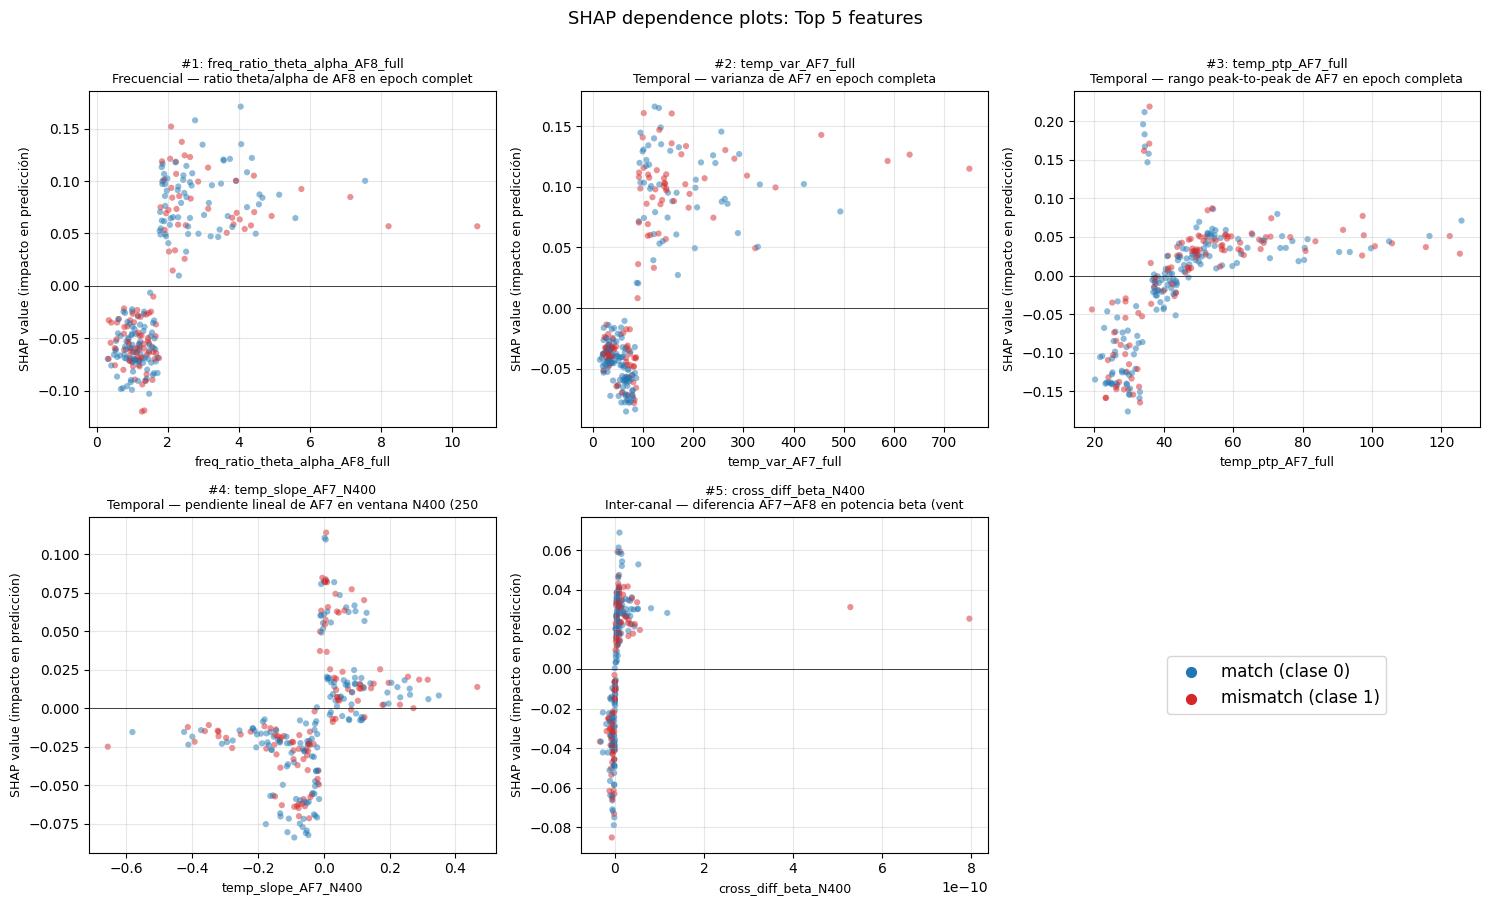

In [12]:
top5_features = df_shap_importance.head(5)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(top5_features):
    ax = axes[i]
    feat_idx = feature_cols.index(feat)
    feat_values = X_ho_raw[feat].values   # valores originales (no escalados)
    shap_vals_feat = shap_values[:, feat_idx]

    # Colorear por etiqueta verdadera
    colors = ['tab:blue' if y == 0 else 'tab:red' for y in y_ho]
    ax.scatter(feat_values, shap_vals_feat, c=colors, alpha=0.5, s=20, edgecolor='none')
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('SHAP value (impacto en predicción)', fontsize=9)
    ax.set_title(f'#{i+1}: {feat}\n{feature_dictionary.get(feat, "")[:55]}', fontsize=9)
    ax.grid(alpha=0.3)

# Leyenda en el último subplot
axes[5].axis('off')
axes[5].scatter([], [], c='tab:blue', label='match (clase 0)', s=50)
axes[5].scatter([], [], c='tab:red', label='mismatch (clase 1)', s=50)
axes[5].legend(loc='center', fontsize=12, frameon=True)

plt.suptitle('SHAP dependence plots: Top 5 features', fontsize=13, y=1.0)
plt.tight_layout()
fig_path = FIGURES_DIR / '07_shap_dependence_top5.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

## 11. Análisis local (casos representativos)

Se seleccionan algunos ejemplos del holdout para entender predicciones individuales: un caso correctamente clasificado con alta confianza, un falso positivo, un falso negativo y un caso cerca del umbral (probabilidad cercana a 0.5). Para cada caso se muestran las features que más aportan a favor o en contra de la clase predicha.

In [13]:
# Predicciones del modelo en holdout
y_pred_ho = best_model.predict(X_ho_raw.values)
y_proba_ho = best_model.predict_proba(X_ho_raw.values)[:, 1]

# Identificar casos
df_cases = pd.DataFrame({
    'idx':    np.arange(len(y_ho)),
    'true':   y_ho,
    'pred':   y_pred_ho,
    'proba':  y_proba_ho,
    'subject': df_ho['subject_id'].values
})

def pick(df_, condition, sort_by, ascending):
    sub = df_[condition].sort_values(sort_by, ascending=ascending)
    return int(sub.iloc[0]['idx']) if len(sub) > 0 else None

case_indices = {
    'TP confidencial':  pick(df_cases, (df_cases['true']==1) & (df_cases['pred']==1), 'proba', False),
    'TN confidencial':  pick(df_cases, (df_cases['true']==0) & (df_cases['pred']==0), 'proba', True),
    'FP':               pick(df_cases, (df_cases['true']==0) & (df_cases['pred']==1), 'proba', False),
    'FN':               pick(df_cases, (df_cases['true']==1) & (df_cases['pred']==0), 'proba', True),
    'Ambiguo (p≈0.5)':  pick(df_cases, np.abs(df_cases['proba']-0.5) < 0.05, 'proba', True),
}

print('=== CASOS REPRESENTATIVOS ===\n')
for label, idx in case_indices.items():
    if idx is None:
        print(f'{label}: no encontrado')
        continue
    r = df_cases.iloc[idx]
    print(f'{label}:')
    print(f'  Sujeto: {r["subject"]}  -  Verdad: {["match","mismatch"][r["true"]]}  -  '
          f'Predicción: {["match","mismatch"][r["pred"]]}  -  prob(mismatch) = {r["proba"]:.3f}')

=== CASOS REPRESENTATIVOS ===

TP confidencial:
  Sujeto: mu17erp  -  Verdad: mismatch  -  Predicción: mismatch  -  prob(mismatch) = 0.603
TN confidencial:
  Sujeto: mu05erp  -  Verdad: match  -  Predicción: match  -  prob(mismatch) = 0.354
FP:
  Sujeto: mu17erp  -  Verdad: match  -  Predicción: mismatch  -  prob(mismatch) = 0.613
FN:
  Sujeto: mu05erp  -  Verdad: mismatch  -  Predicción: match  -  prob(mismatch) = 0.354
Ambiguo (p≈0.5):
  Sujeto: mu17erp  -  Verdad: mismatch  -  Predicción: match  -  prob(mismatch) = 0.450


 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/07_shap_local_cases.png


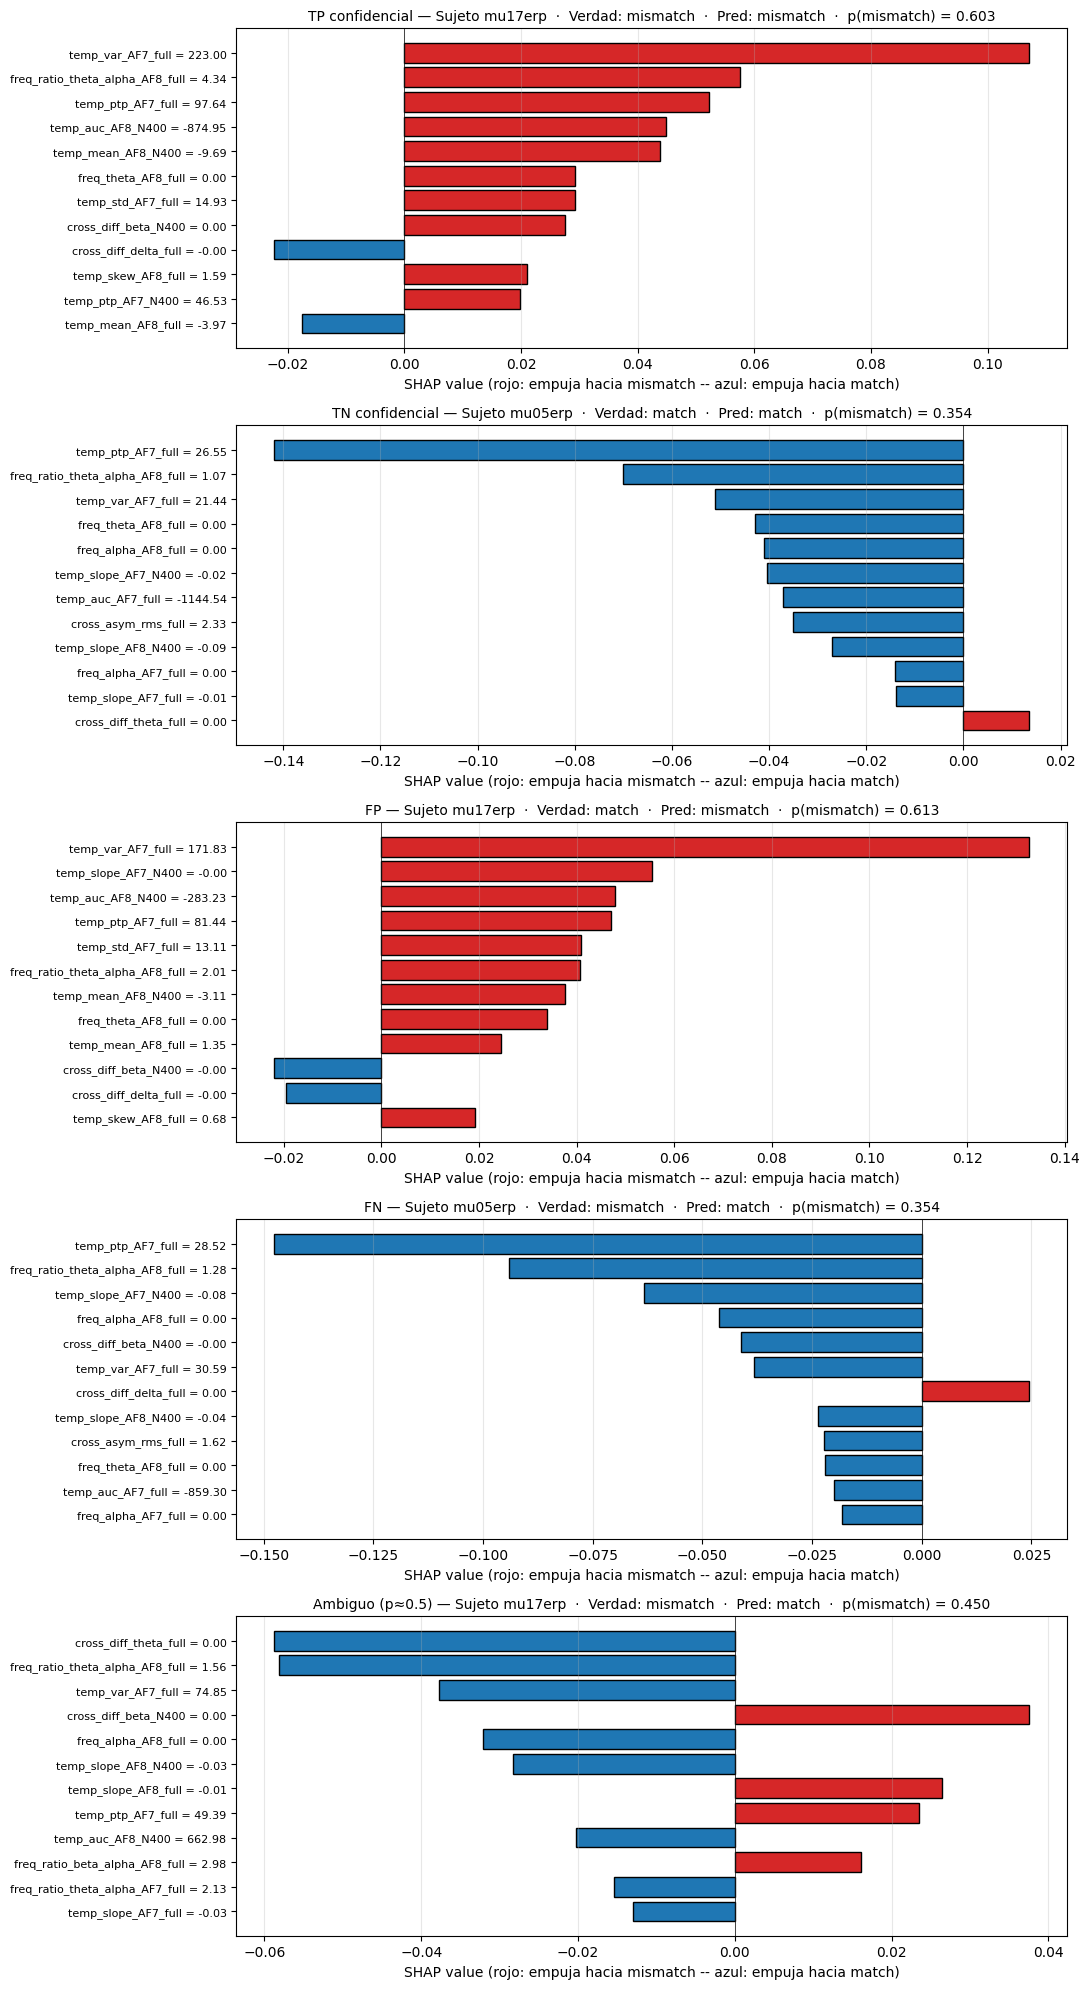

In [14]:
# Visualización tipo waterfall para cada caso
n_cases = sum(1 for v in case_indices.values() if v is not None)
fig, axes = plt.subplots(n_cases, 1, figsize=(11, 4 * n_cases))
if n_cases == 1:
    axes = [axes]

for ax, (label, idx) in zip(axes, [(k, v) for k, v in case_indices.items() if v is not None]):
    shap_row = shap_values[idx]
    # Top 12 features por contribución absoluta
    top_indices = np.argsort(np.abs(shap_row))[::-1][:12]
    top_features_names = [feature_cols[i] for i in top_indices]
    top_shaps = shap_row[top_indices]
    top_values = X_ho_raw.iloc[idx][top_features_names].values

    colors = ['tab:red' if v > 0 else 'tab:blue' for v in top_shaps]
    y_pos = np.arange(len(top_shaps))[::-1]
    ax.barh(y_pos, top_shaps, color=colors, edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f'{name} = {val:.2f}' for name, val in zip(top_features_names, top_values)], fontsize=8)
    ax.axvline(0, color='k', linewidth=0.5)

    r = df_cases.iloc[idx]
    ax.set_title(
        f'{label} — Sujeto {r["subject"]}  ·  '
        f'Verdad: {["match","mismatch"][r["true"]]}  ·  '
        f'Pred: {["match","mismatch"][r["pred"]]}  ·  '
        f'p(mismatch) = {r["proba"]:.3f}',
        fontsize=10
    )
    ax.set_xlabel('SHAP value (rojo: empuja hacia mismatch -- azul: empuja hacia match)')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig_path = FIGURES_DIR / '07_shap_local_cases.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()